In [2]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if "feature" in file.lower():
            print(os.path.join(root, file))

/kaggle/input/datasets/sanjanaashetty/data-alarm/feature_dataset.parquet


In [3]:
import pandas as pd

df = pd.read_parquet(
    "/kaggle/input/datasets/sanjanaashetty/data-alarm/feature_dataset.parquet"
)

print(df.shape)
df.head()

(1737509, 239)


,TimeStamp,02FI_1000.PV,03FIC_1085.PV,03FI_3418.PV,03LIC_1094.PV,03PIC_1104.PV,03TIC_1009.PV,03TIC_1092.PV,03TI_1002.PV,03TI_1005.PV,...,03TI_1108.PV_roc_1,03TI_1108.PV_roc_5,03TI_1108.PV_roc_15,03TI_1404.PV_roc_1,03TI_1404.PV_roc_5,03TI_1404.PV_roc_15,target_future_5,target_future_10,target_future_15,target_min_next_15
0,2022-01-03 23:46:00,6.663997,229.69188,33.437412,54.767050,26.054886,37.638160,4.257061,45.113630,42.495970,...,0.000000,0.045290,0.396304,-0.388073,-0.719358,-1.069568,38.451874,38.225850,39.107365,37.47994
1,2022-01-03 23:47:00,6.697112,230.28848,33.225487,58.283463,26.069012,37.773785,4.304153,45.056650,43.367107,...,-0.011325,0.011318,0.384979,-0.274494,-0.880268,-1.353527,38.056324,38.158035,38.915240,37.47994
2,2022-01-03 23:48:00,6.660269,226.15488,33.022038,57.716550,26.087847,38.316257,4.153465,45.028156,42.997818,...,0.090585,0.101903,0.407624,-0.454331,-1.258877,-1.637486,37.932003,38.191936,38.191936,37.47994
3,2022-01-03 23:49:00,6.674368,228.32820,33.344166,57.660084,26.054886,37.898100,4.172302,45.066143,42.751633,...,-0.056610,0.067940,0.339696,0.265027,-0.984382,-0.908660,37.920704,38.203240,37.762480,37.47994
4,2022-01-03 23:50:00,6.670408,223.64062,33.462840,58.140785,26.059595,38.112830,4.059284,45.170616,43.575417,...,0.045283,0.067933,0.305713,-0.179837,-1.031708,-1.306198,38.327553,38.644000,37.739880,37.47994


In [4]:
print(df.shape)

print("\nTarget present:")
print("target_min_next_15" in df.columns)

print("\nTimestamp present:")
print("TimeStamp" in df.columns)

print("\nColumns:")
print(len(df.columns))

(1737509, 239)

Target present:
True

Timestamp present:
True

Columns:
239


In [5]:
import pandas as pd
import numpy as np
import pickle

from sklearn.preprocessing import StandardScaler

DATA_PATH = (
    "/kaggle/input/datasets/sanjanaashetty/data-alarm/feature_dataset.parquet"
)

df = pd.read_parquet(DATA_PATH)

print("Dataset Shape:", df.shape)

SENSOR_COLS = [
    "02FI_1000.PV",
    "03FIC_1085.PV",
    "03FI_3418.PV",
    "03LIC_1094.PV",
    "03PIC_1104.PV",
    "03TIC_1009.PV",
    "03TIC_1092.PV",
    "03TI_1002.PV",
    "03TI_1005.PV",
    "03TI_1081.PV",
    "03TI_1102.PV",
    "03TI_1108.PV",
    "03TI_1404.PV"
]

TARGET_COL = "target_min_next_15"

# same split as GRU

n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

print("\nTrain:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

# scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(
    train_df[SENSOR_COLS]
)

X_val = scaler.transform(
    val_df[SENSOR_COLS]
)

X_test = scaler.transform(
    test_df[SENSOR_COLS]
)

y_train = train_df[TARGET_COL].values
y_val = val_df[TARGET_COL].values
y_test = test_df[TARGET_COL].values

with open("/kaggle/working/scaler.pkl","wb") as f:
    pickle.dump(scaler,f)

print("\nScaler saved")

Dataset Shape: (1737509, 239)

Train: (1216256, 239)
Val: (260626, 239)
Test: (260627, 239)

Scaler saved


In [6]:
LOOKBACK = 60

def create_sequences(X, y, lookback):

    X_seq = []
    y_seq = []

    for i in range(lookback, len(X)):

        X_seq.append(
            X[i-lookback:i]
        )

        y_seq.append(
            y[i]
        )

    return (
        np.array(X_seq),
        np.array(y_seq)
    )

X_train_seq, y_train_seq = create_sequences(
    X_train,
    y_train,
    LOOKBACK
)

X_val_seq, y_val_seq = create_sequences(
    X_val,
    y_val,
    LOOKBACK
)

X_test_seq, y_test_seq = create_sequences(
    X_test,
    y_test,
    LOOKBACK
)

print(X_train_seq.shape)
print(X_val_seq.shape)
print(X_test_seq.shape)

(1216196, 60, 13)
(260566, 60, 13)
(260567, 60, 13)


In [7]:
print(TARGET_COL)

target_min_next_15


In [8]:
import torch
import torch.nn as nn

from torch.utils.data import (
    TensorDataset,
    DataLoader
)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

X_train_tensor = torch.tensor(
    X_train_seq,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val_seq,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_seq,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train_seq,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val_seq,
    dtype=torch.float32
)

train_loader = DataLoader(
    TensorDataset(
        X_train_tensor,
        y_train_tensor
    ),
    batch_size=256,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(
        X_val_tensor,
        y_val_tensor
    ),
    batch_size=256,
    shuffle=False
)

class TransformerRegressor(nn.Module):

    def __init__(
        self,
        n_features=13,
        d_model=32,
        nhead=4,
        num_layers=2
    ):

        super().__init__()

        self.input_proj = nn.Linear(
            n_features,
            d_model
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            batch_first=True,
            dropout=0.1
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.fc = nn.Sequential(
            nn.Linear(d_model,64),
            nn.ReLU(),
            nn.Linear(64,1)
        )

    def forward(self,x):

        x = self.input_proj(x)

        x = self.transformer(x)

        x = x[:,-1,:]

        return self.fc(x).squeeze()

model = TransformerRegressor().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

EPOCHS = 10

train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    model.train()

    train_loss = 0

    for X_batch,y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        pred = model(X_batch)

        loss = criterion(
            pred,
            y_batch
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()

    val_loss = 0

    with torch.no_grad():

        for X_batch,y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(X_batch)

            loss = criterion(
                pred,
                y_batch
            )

            val_loss += loss.item()

    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.5f} | "
        f"Val Loss: {val_loss:.5f}"
    )

Device: cuda
Epoch 1/10 | Train Loss: 23.30323 | Val Loss: 0.41404
Epoch 2/10 | Train Loss: 0.13931 | Val Loss: 0.24119
Epoch 3/10 | Train Loss: 0.11693 | Val Loss: 0.24602
Epoch 4/10 | Train Loss: 0.10415 | Val Loss: 0.29964
Epoch 5/10 | Train Loss: 0.09905 | Val Loss: 0.24397
Epoch 6/10 | Train Loss: 0.09253 | Val Loss: 0.33734
Epoch 7/10 | Train Loss: 0.08987 | Val Loss: 0.36049
Epoch 8/10 | Train Loss: 0.08697 | Val Loss: 0.20849
Epoch 9/10 | Train Loss: 0.08532 | Val Loss: 0.33610
Epoch 10/10 | Train Loss: 0.08578 | Val Loss: 0.18135


In [9]:
import os
import torch

SAVE_PATH = "/kaggle/working/transformer_model.pt"

torch.save(
    model.state_dict(),
    SAVE_PATH
)

print("Saved:", SAVE_PATH)
print("Exists:", os.path.exists(SAVE_PATH))

Saved: /kaggle/working/transformer_model.pt
Exists: True


In [10]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    confusion_matrix,
    classification_report
)

test_loader = DataLoader(
    TensorDataset(
        X_test_tensor
    ),
    batch_size=1024,
    shuffle=False
)

model.eval()

predictions = []

with torch.no_grad():

    for (X_batch,) in test_loader:

        X_batch = X_batch.to(device)

        pred = model(X_batch)

        predictions.extend(
            pred.cpu().numpy()
        )

test_pred = np.array(predictions)

y_true = y_test_seq

mae = mean_absolute_error(
    y_true,
    test_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_true,
        test_pred
    )
)

r2 = r2_score(
    y_true,
    test_pred
)

print("\nRegression Metrics")
print("MAE :", round(mae,4))
print("RMSE:", round(rmse,4))
print("R²  :", round(r2,4))

THRESHOLD = 30.5

actual_alarm = (
    y_true < THRESHOLD
).astype(int)

pred_alarm = (
    test_pred < THRESHOLD
).astype(int)

print("\nConfusion Matrix")
print(
    confusion_matrix(
        actual_alarm,
        pred_alarm
    )
)

print("\nClassification Report")
print(
    classification_report(
        actual_alarm,
        pred_alarm,
        digits=4
    )
)


Regression Metrics
MAE : 0.2645
RMSE: 0.6019
R²  : 0.9748

Confusion Matrix
[[260415     17]
 [    52     83]]

Classification Report
              precision    recall  f1-score   support

           0     0.9998    0.9999    0.9999    260432
           1     0.8300    0.6148    0.7064       135

    accuracy                         0.9997    260567
   macro avg     0.9149    0.8074    0.8531    260567
weighted avg     0.9997    0.9997    0.9997    260567



In [11]:
test_times = (
    test_df["TimeStamp"]
    .iloc[LOOKBACK:]
    .reset_index(drop=True)
)

results = pd.DataFrame({
    "timestamp": test_times,
    "actual": y_true,
    "predicted": test_pred
})

results["actual_alarm"] = (
    results["actual"] < THRESHOLD
).astype(int)

results["pred_alarm"] = (
    results["predicted"] < THRESHOLD
).astype(int)

def build_events(times,gap_minutes=30):

    if len(times)==0:
        return []

    times = sorted(times)

    events=[]

    start=times[0]
    prev=times[0]

    for t in times[1:]:

        gap = (
            t-prev
        ).total_seconds()/60

        if gap>gap_minutes:

            events.append(
                (start,prev)
            )

            start=t

        prev=t

    events.append(
        (start,prev)
    )

    return events

actual_events = build_events(
    results.loc[
        results.actual_alarm==1,
        "timestamp"
    ].tolist()
)

pred_events = build_events(
    results.loc[
        results.pred_alarm==1,
        "timestamp"
    ].tolist()
)

detected = 0

for a_start,a_end in actual_events:

    found=False

    for p_start,p_end in pred_events:

        overlap = (
            p_start<=a_end
            and
            p_end>=a_start
        )

        if overlap:

            found=True
            break

    if found:
        detected += 1

print("\nActual Events :", len(actual_events))
print("Detected Events:", detected)

print(
    "Event Recall:",
    round(
        detected/len(actual_events),
        4
    )
)


Actual Events : 5
Detected Events: 3
Event Recall: 0.6


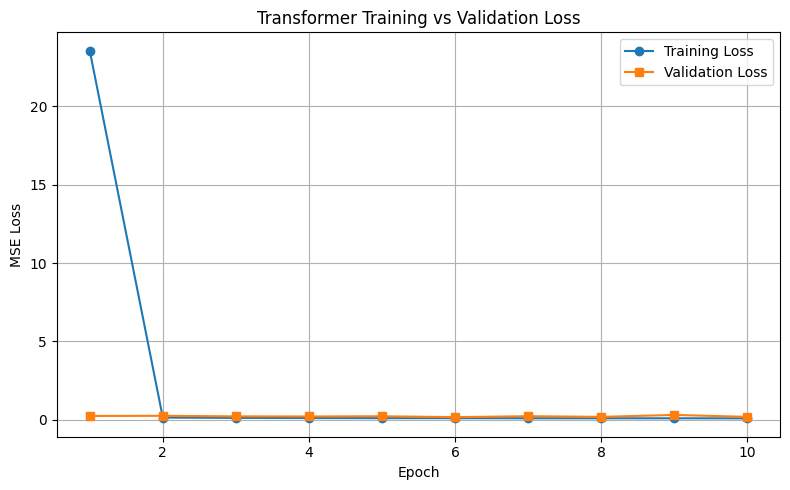

In [12]:
import matplotlib.pyplot as plt

train_losses = [
    23.55495,
    0.13700,
    0.11617,
    0.10496,
    0.09848,
    0.09921,
    0.09349,
    0.09134,
    0.09096,
    0.08823
]

val_losses = [
    0.24005,
    0.24866,
    0.21376,
    0.20675,
    0.22066,
    0.16497,
    0.22557,
    0.18200,
    0.30525,
    0.18310
]

epochs = range(1, 11)

plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    val_losses,
    marker="s",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Transformer Training vs Validation Loss")

plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig(
    "/kaggle/working/transformer_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
'''SHAP (GRU + Transformer)
      ↓
Top 30–50 important features
      ↓
Correlation matrix on only those features
      ↓
Remove redundant features
      ↓
Retrain 


1. SHAP analysis on the current GRU and Transformer (13 original variables).
2. Identify the most influential sensors.
3. Correlation analysis among engineered features derived from those sensors.
4. Remove redundant features.
5. Scale all selected features.
6. Retrain GRU and Transformer using:
    -original features
    -selected engineered features
7. Try larger model configurations (d_model=64, more layers, etc.).''' 

'SHAP (GRU + Transformer)\n      ↓\nTop 30–50 important features\n      ↓\nCorrelation matrix on only those features\n      ↓\nRemove redundant features\n      ↓\nRetrain \n\n\n1. SHAP analysis on the current GRU and Transformer (13 original variables).\n2. Identify the most influential sensors.\n3. Correlation analysis among engineered features derived from those sensors.\n4. Remove redundant features.\n5. Scale all selected features.\n6. Retrain GRU and Transformer using:\n    -original features\n    -selected engineered features\n7. Try larger model configurations (d_model=64, more layers, etc.).'

In [14]:
print(os.path.exists("/kaggle/working/transformer_model.pt"))

True
